In [1]:
import pandas as pd
import numpy as np
import seaborn as sea
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from kagglehub.datasets import dataset_download
import kagglehub
from google.colab import userdata

KAGGLE_API_KEY = userdata.get('KAGGLE_API_KEY')

#Downloading using kagglehub.dataset_download
dataset_handle = "yash9439/ipl-dataset"
path = kagglehub.dataset_download(dataset_handle)

print(f"Path to dataset files: {path}")


Using Colab cache for faster access to the 'ipl-dataset' dataset.
Path to dataset files: /kaggle/input/ipl-dataset


In [3]:
dataset = pd.read_csv("/kaggle/input/ipl-dataset/matches.csv")

In [4]:
dataset.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [6]:
dataset.describe()

,id,season,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,2013.444444,0.025132,13.283069,3.350529
std,3464.478148,3.366895,0.156630,23.471144,3.387963
min,1.000000,2008.000000,0.000000,0.000000,0.000000
25%,189.750000,2011.000000,0.000000,0.000000,0.000000
50%,378.500000,2013.000000,0.000000,0.000000,4.000000
75%,567.250000,2016.000000,0.000000,19.000000,6.000000
max,11415.000000,2019.000000,1.000000,146.000000,10.000000


In [7]:
dataset.isnull().sum()

,0
id,0
season,0
city,7
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [8]:
dataset['season'].value_counts()

,count
season,
2013,76
2012,74
2011,73
2010,60
2016,60
2018,60
2019,60
2014,60
2017,59


In [9]:
dataset['dl_applied'].value_counts()

,count
dl_applied,
0,737
1,19


In [10]:
match_dataset= dataset.copy()

Filling Missing Umpire Values

In [11]:
match_dataset['umpire3']=match_dataset['umpire3'].fillna('umpire3')

In [12]:
umpire1_mode = match_dataset['umpire1'].mode()[0]
umpire2_mode = match_dataset['umpire2'].mode()[0]

match_dataset['umpire1'] = match_dataset['umpire1'].fillna(umpire1_mode)
match_dataset['umpire2'] = match_dataset['umpire2'].fillna(umpire2_mode)

Filling Missing winner and potm as the match was cancelled due to rain

In [13]:
match_dataset['winner'] = match_dataset['winner'].fillna("Tie")
match_dataset['player_of_match'] =match_dataset['player_of_match'].fillna("No Winner")

In [14]:
print(f"Dataset Cleaned")
display(match_dataset.isnull().sum())

Dataset Cleaned


,0
id,0
season,0
city,7
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [15]:
# Get venues where city is null
venues_with_null_city = match_dataset[match_dataset['city'].isnull()]['venue'].unique()
print(f"Venues with null cities: {venues_with_null_city}")

Venues with null cities: ['Dubai International Cricket Stadium']


In [16]:
# Create a mapping from venue to city using non-null entries
venue_to_city_mapping = match_dataset.dropna(subset=['city']).groupby('venue')['city'].agg(lambda x: x.mode()[0]).to_dict()

In [17]:
print(f"Number of null values in 'city' after filling: {match_dataset['city'].isnull().sum()}")

Number of null values in 'city' after filling: 7


In [18]:
match_dataset.loc[match_dataset['venue'] == 'Dubai International Cricket Stadium', 'city'] = 'Dubai'

In [19]:
match_dataset.columns

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')

In [20]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [21]:
# top_winners
# top_losers
# toss_winners_and_toss_decision_relation_of_toss_decision_with_winn
# most_winners_by_wicketandruns
# top_player_of_the_match
# most_played_city
# city_and_team1(hometeam)relation
# city_and_team2_relation
# toss_winnerv/s_game_winner
# season_wise_srting_and_analysis.
# win_percent
# performance_trend_per_season
# dl_applied_wicket_and_run_groupby
# toss_won_and_choose_percent_pie_chart

In [22]:
numerical_columns = [feature for feature in dataset.columns if dataset[feature].dtype != 'object' and feature not in ['id']]

display(numerical_columns)

['season', 'dl_applied', 'win_by_runs', 'win_by_wickets']

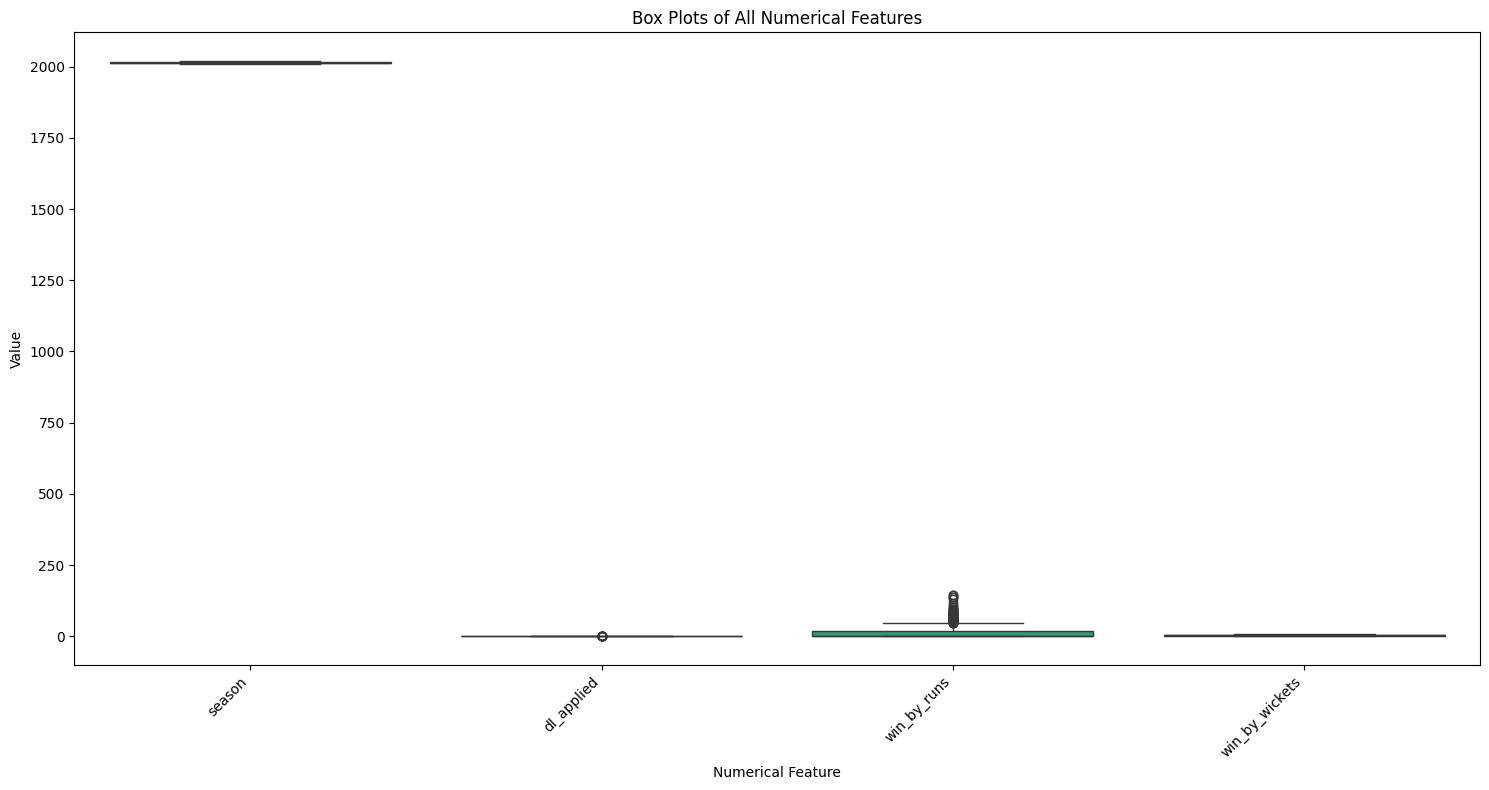

In [23]:
#Vectorised boxplotfor numerical features

melted_data_before_capping = match_dataset.melt(value_vars=numerical_columns,
                                                var_name='Numerical Feature',
                                                value_name="Value")

plt.figure(figsize=(15,8))
sea.boxplot(x='Numerical Feature', y='Value', hue='Numerical Feature',data=melted_data_before_capping,palette='viridis',legend=False)
plt.title("Box Plots of All Numerical Features")
plt.xlabel('Numerical Feature')
plt.ylabel('Value')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

Decided to keep the outliers because in a cricket match these things are quite possible

In [24]:
dataset['team1'].value_counts()

,count
team1,
Mumbai Indians,101
Kings XI Punjab,91
Chennai Super Kings,89
Royal Challengers Bangalore,85
Kolkata Knight Riders,83
Delhi Daredevils,72
Rajasthan Royals,67
Sunrisers Hyderabad,63
Deccan Chargers,43


### Standardizing Team Names

Based on the `value_counts()` output, we need to address a few team name inconsistencies for better analysis:

*   `Rising Pune Supergiant` and `Rising Pune Supergiants` are the same team.
*   `Delhi Daredevils` changed to `Delhi Capitals`.
*   `Deccan Chargers` was a predecessor to `Sunrisers Hyderabad`.

Let's create a mapping and apply these changes to the `match_dataset`.

In [25]:
team_name_mapp = {
                  'Rising Pune Supergiants' : 'Rising Pune Supergiant',
                  'Rising Pune Supergiats' : 'Rising Pune Supergiant',
                  'Delhi Daredevils':'Delhi Capitals',
                  'Deccan Chargers':'Sunrisers Hyderabad'
}

def standardize_team_names(df,columns):
  for col in columns:
    df[col] = df[col].replace(team_name_mapp)
  return df

team_columns =['team1','team2','toss_winner','winner']
match_dataset= standardize_team_names(match_dataset,team_columns)

In [26]:
# top_winners
# top_losers
# toss_winners
# most_winners_by_wicketandruns
# top_player_of_the_match
# most_played_city
# city_and_team1(hometeam)relation
# city_and_team2_relation
# toss_winnerv/s_game_winner
# season_wise_srting_and_analysis.
# win_percent
# performance_trend_per_season
# dl_applied_wicket_and_run_groupby

In [27]:
match_dataset['winner'].value_counts().head(10)

,count
winner,
Mumbai Indians,109
Chennai Super Kings,100
Kolkata Knight Riders,92
Sunrisers Hyderabad,87
Royal Challengers Bangalore,84
Kings XI Punjab,82
Delhi Capitals,77
Rajasthan Royals,75
Rising Pune Supergiant,15


In [28]:
match_dataset['winner'].value_counts(ascending=True).head(10)

,count
winner,
Tie,4
Kochi Tuskers Kerala,6
Pune Warriors,12
Gujarat Lions,13
Rising Pune Supergiant,15
Rajasthan Royals,75
Delhi Capitals,77
Kings XI Punjab,82
Royal Challengers Bangalore,84


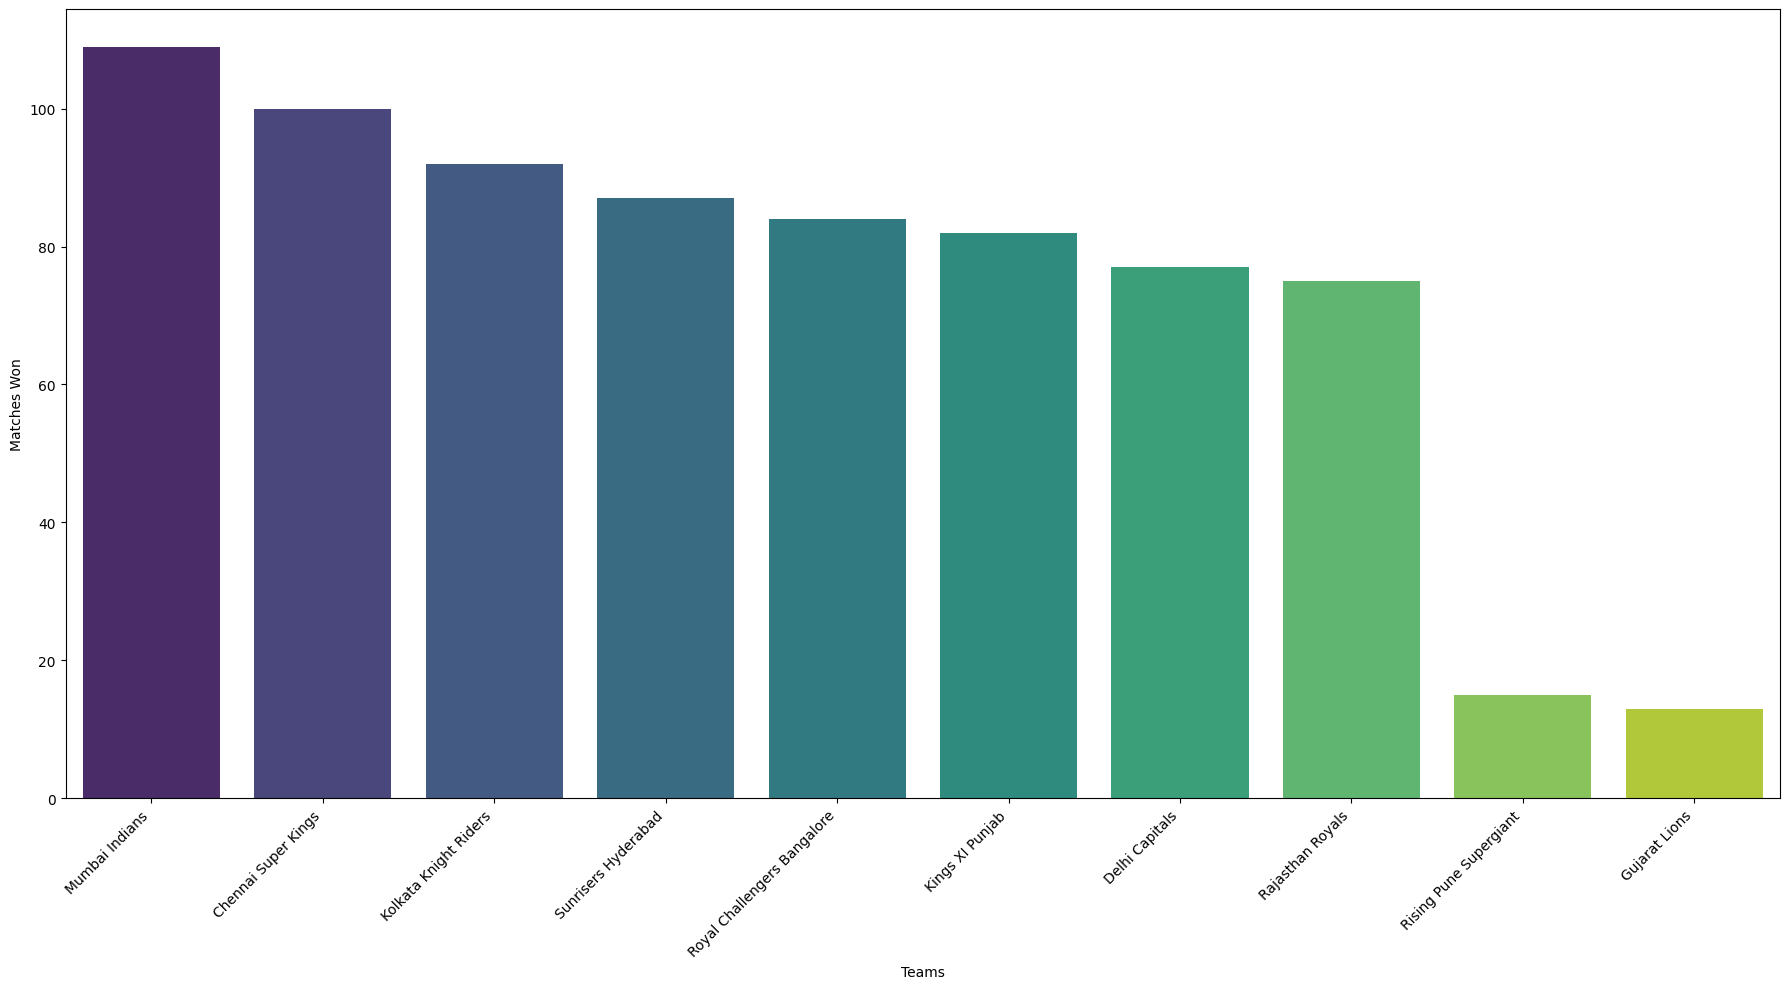

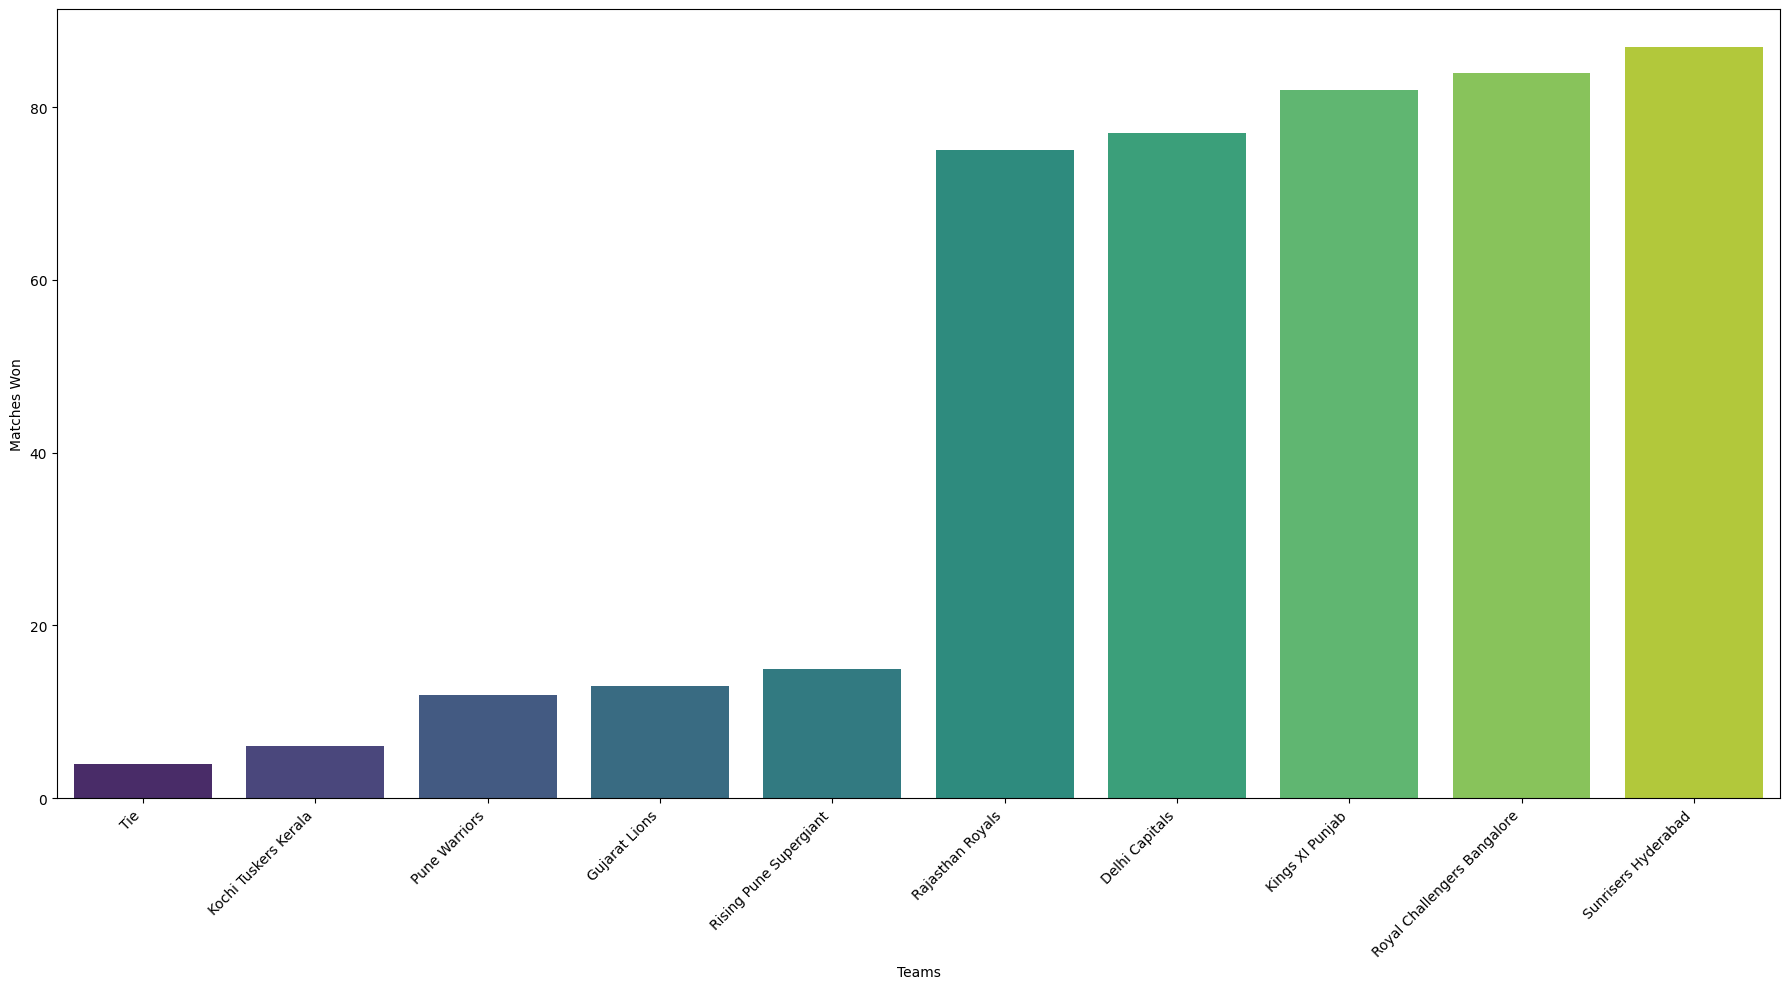

In [29]:
top_10_winners = match_dataset['winner'].value_counts().head(10)
top_10_losers = match_dataset['winner'].value_counts(ascending=True).head(10)


top_10_winners= top_10_winners.reset_index()

plt.figure(figsize=(18,10))
sea.barplot(x='winner',y='count',data=top_10_winners,hue='winner',palette='viridis',legend=False)
plt.xlabel("Teams")
plt.ylabel("Matches Won")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top_10_losers= top_10_losers.reset_index()
plt.figure(figsize=(18,10))
sea.barplot(x='winner',y='count',data=top_10_losers,hue='winner',palette='viridis',legend=False)
plt.xlabel("Teams")
plt.ylabel("Matches Won")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [30]:
match_dataset['loser'] = np.where(match_dataset['winner'] ==
                                  match_dataset['team1'], match_dataset['team2'], match_dataset['team1'])
match_dataset.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,loser
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,umpire3,Royal Challengers Bangalore
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,umpire3,Mumbai Indians
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,umpire3,Gujarat Lions
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,umpire3,Rising Pune Supergiant
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,HDPK Dharmasena,C Shamshuddin,umpire3,Delhi Capitals


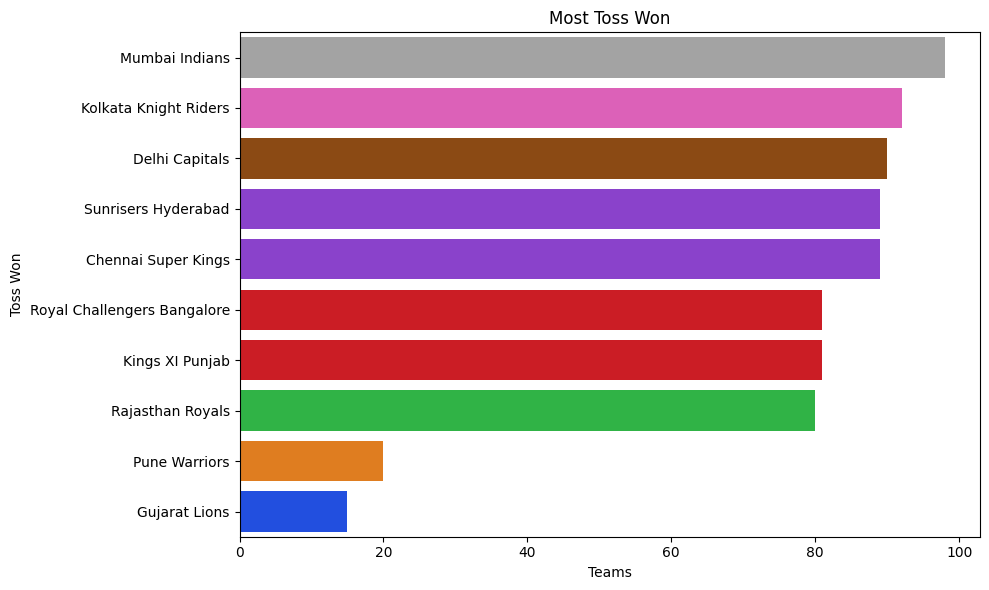

In [31]:
#Toss_winners
toss_winner= match_dataset['toss_winner'].value_counts().head(10)
toss_winner=toss_winner.reset_index()

plt.figure(figsize=(10,6))
sea.barplot(x='count',y='toss_winner',data=toss_winner,hue='count',palette='bright',legend=False)
plt.title("Most Toss Won")
plt.xlabel("Teams")
plt.ylabel("Toss Won")
plt.tight_layout()
plt.show()

In [32]:
toss_decision_counts = match_dataset['toss_decision'].value_counts()
display(toss_decision_counts)
total_decisions = toss_decision_counts.sum()
display(f"Total Decisions: {total_decisions}")

descision_percent = (toss_decision_counts/total_decisions) * 100
display(descision_percent)

,count
toss_decision,
field,463
bat,293


'Total Decisions: 756'

,count
toss_decision,
field,61.243386
bat,38.756614


In [33]:
#toss_winner_and_match_winner

toss_and_match_winner = match_dataset.groupby('toss_winner')['winner'].value_counts()
# display(toss_and_match_winner)

toss_and_match_winner = match_dataset[match_dataset['toss_winner']==match_dataset['winner']].groupby('toss_winner').size().sort_values(ascending=False)

toss_and_match_winner = toss_and_match_winner.reset_index()
toss_and_match_winner.rename(columns={0:'Match Won'},inplace=True)
display(toss_and_match_winner)

,toss_winner,Match Won
0,Chennai Super Kings,57
1,Mumbai Indians,56
2,Kolkata Knight Riders,53
3,Delhi Capitals,42
4,Sunrisers Hyderabad,42
5,Rajasthan Royals,42
6,Royal Challengers Bangalore,41
7,Kings XI Punjab,35
8,Gujarat Lions,10
9,Rising Pune Supergiant,8


In [34]:
toss_decision_and_winner = match_dataset.groupby('toss_decision')['winner'].value_counts()
display(toss_decision_and_winner)
# toss_decision_and_winner = toss_decision_and_winner.reset_index()
# toss_decision_and_winner

toss_decision  winner                     
bat            Chennai Super Kings            52
               Mumbai Indians                 45
               Kolkata Knight Riders          35
               Sunrisers Hyderabad            35
               Rajasthan Royals               34
               Delhi Capitals                 31
               Royal Challengers Bangalore    26
               Kings XI Punjab                21
               Pune Warriors                   9
               Gujarat Lions                   2
               Rising Pune Supergiant          2
               Tie                             1
field          Mumbai Indians                 64
               Kings XI Punjab                61
               Royal Challengers Bangalore    58
               Kolkata Knight Riders          57
               Sunrisers Hyderabad            52
               Chennai Super Kings            48
               Delhi Capitals                 46
               Rajasthan Royals               41
               Rising Pune Supergiant         13
               Gujarat Lions                  11
               Kochi Tuskers Kerala            6
               Pune Warriors                   3
               Tie                             3
Name: count, dtype: int64

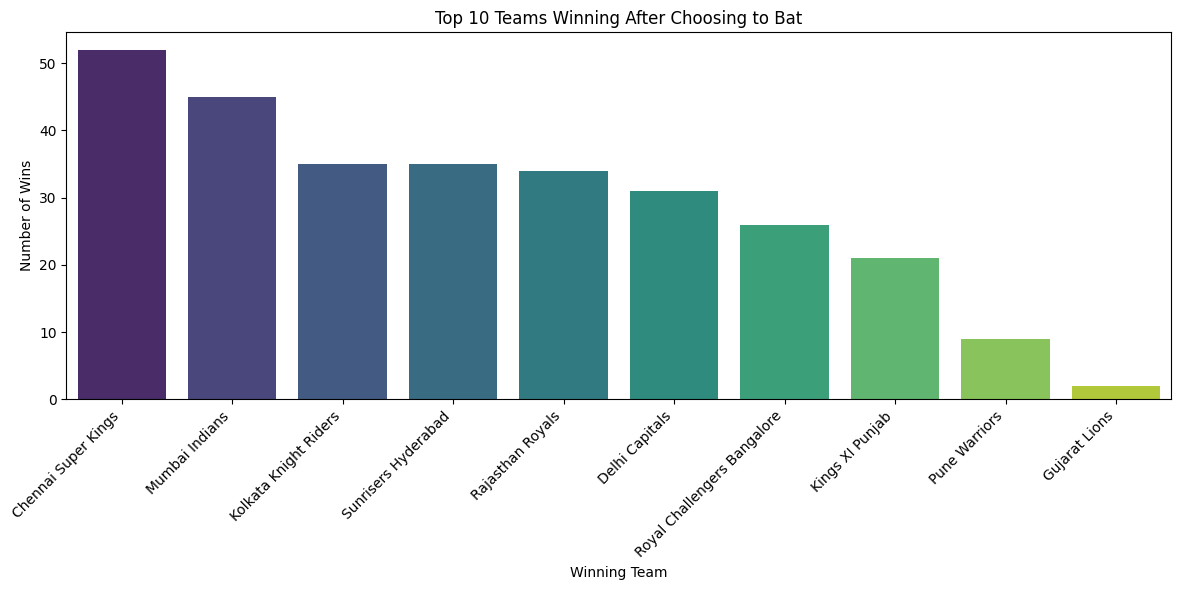

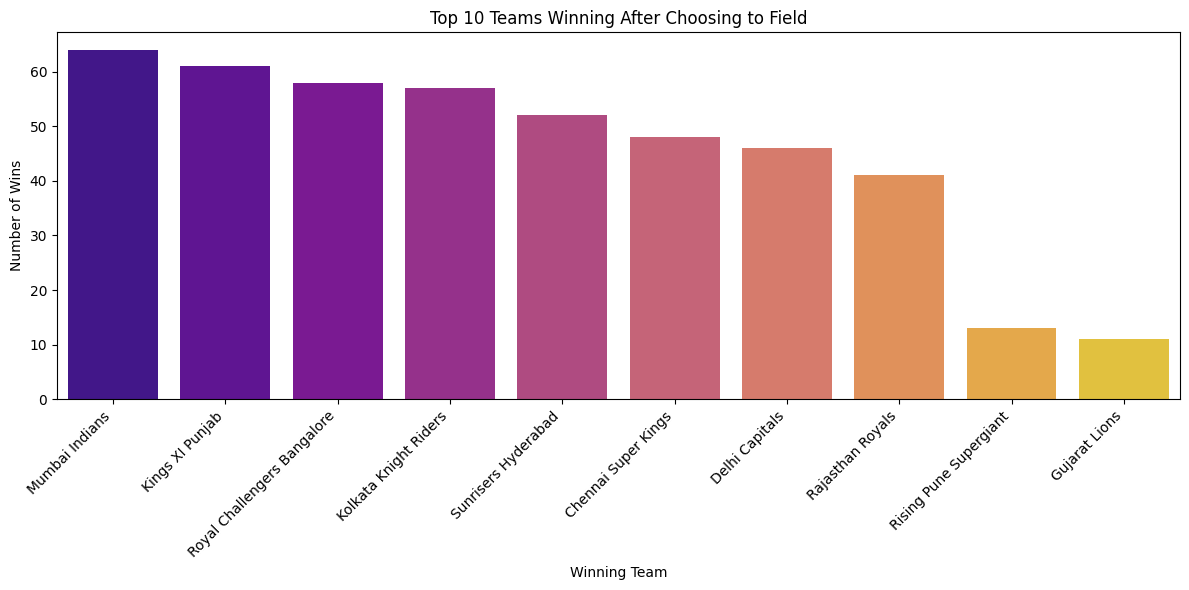

In [35]:
# Separate the data for 'bat' and 'field' decisions
win_after_bat = toss_decision_and_winner.loc['bat'].sort_values(ascending=False).head(10)
win_after_field = toss_decision_and_winner.loc['field'].sort_values(ascending=False).head(10)

# Plot for wins after choosing to Bat
plt.figure(figsize=(12, 6))
sea.barplot(x=win_after_bat.index, y=win_after_bat.values, palette='viridis', hue=win_after_bat.index, legend=False)
plt.title('Top 10 Teams Winning After Choosing to Bat')
plt.xlabel('Winning Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot for wins after choosing to Field
plt.figure(figsize=(12, 6))
sea.barplot(x=win_after_field.index, y=win_after_field.values, palette='plasma', hue=win_after_field.index, legend=False)
plt.title('Top 10 Teams Winning After Choosing to Field')
plt.xlabel('Winning Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()